In [2]:
import cv2
import numpy as np

# Exemplo de imagem
image = np.array([
    [0, 0, 1, 1, 0],
    [0, 1, 1, 0, 0],
    [1, 1, 0, 0, 1],
    [0, 0, 1, 1, 1],
    [0, 1, 1, 0, 0]
], dtype=np.uint8)

# Encontrar as bordas utilizando Canny
edges = cv2.Canny(image, 100, 200)

# Aplicar a transformada de distância
dist_transform = cv2.distanceTransform(image, cv2.DIST_L2, 5)

# Aplicar o limiar para obter as sementes
_, markers = cv2.threshold(dist_transform, 0.7 * dist_transform.max(), 255, 0)
markers = np.uint8(markers)

# Marcadores para o algoritmo de watershed
_, markers = cv2.connectedComponents(markers)
markers = markers + 1
markers[edges == 255] = 0

# Aplicar o algoritmo de watershed
image_color = cv2.cvtColor(image * 255, cv2.COLOR_GRAY2BGR)
cv2.watershed(image_color, markers)

print("Markers:", markers)


Markers: [[-1 -1 -1 -1 -1]
 [-1  2  2  1 -1]
 [-1  2  1  1 -1]
 [-1  1  2  2 -1]
 [-1 -1 -1 -1 -1]]


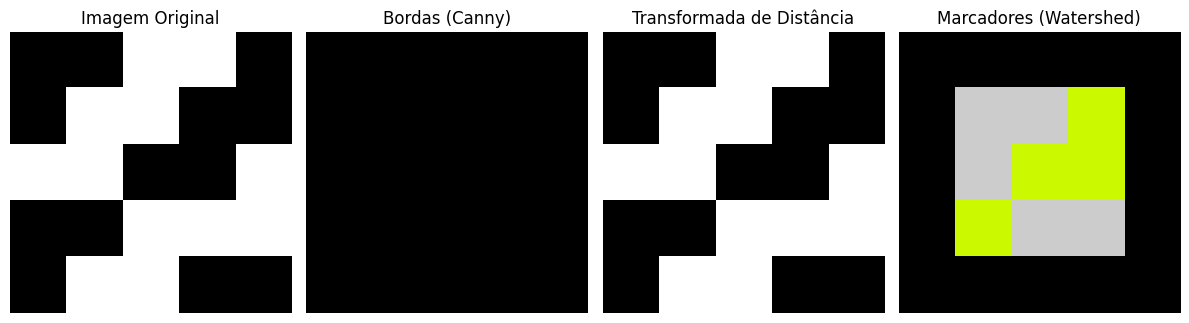

Markers:
 [[-1 -1 -1 -1 -1]
 [-1  2  2  1 -1]
 [-1  2  1  1 -1]
 [-1  1  2  2 -1]
 [-1 -1 -1 -1 -1]]


In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Exemplo de imagem
image = np.array([
    [0, 0, 1, 1, 0],
    [0, 1, 1, 0, 0],
    [1, 1, 0, 0, 1],
    [0, 0, 1, 1, 1],
    [0, 1, 1, 0, 0]
], dtype=np.uint8)

# Encontrar as bordas utilizando Canny
edges = cv2.Canny(image, 100, 200)

# Aplicar a transformada de distância
dist_transform = cv2.distanceTransform(image, cv2.DIST_L2, 5)

# Aplicar o limiar para obter as sementes
_, markers = cv2.threshold(dist_transform, 0.7 * dist_transform.max(), 255, 0)
markers = np.uint8(markers)

# Marcadores para o algoritmo de watershed
_, markers = cv2.connectedComponents(markers)
markers = markers + 1
markers[edges == 255] = 0

# Aplicar o algoritmo de watershed
image_color = cv2.cvtColor(image * 255, cv2.COLOR_GRAY2BGR)
cv2.watershed(image_color, markers)

# Visualizar os resultados
plt.figure(figsize=(12, 6))

# Imagem Original
plt.subplot(1, 4, 1)
plt.imshow(image, cmap='gray')
plt.title('Imagem Original')
plt.axis('off')

# Bordas encontradas pelo Canny
plt.subplot(1, 4, 2)
plt.imshow(edges, cmap='gray')
plt.title('Bordas (Canny)')
plt.axis('off')

# Transformada de Distância
plt.subplot(1, 4, 3)
plt.imshow(dist_transform, cmap='gray')
plt.title('Transformada de Distância')
plt.axis('off')

# Marcadores de Watershed
plt.subplot(1, 4, 4)
plt.imshow(markers, cmap='nipy_spectral')
plt.title('Marcadores (Watershed)')
plt.axis('off')

plt.tight_layout()
plt.show()

print("Markers:\n", markers)


NameError: name 'resultados_kmeans' is not defined

In [5]:
pip install porespy

Note: you may need to restart the kernel to use updated packages.


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage as ndi

In [83]:
import porespy as ps

# Generate a synthetic 2D porous material image
im = ps.generators.blobs(shape=[200, 200], porosity=0.28, blobiness=2)
im = im.astype('uint8')
# Threshold the image to separate void space and solid matrix
threshold_value = 0.5  # Adjust this threshold as needed
#binary_image = (im > threshold_value).astype(int)
binary_image = im > threshold_value
# Label connected components in the binary image
labeled_image, num_labels = ndi.label(binary_image)

In [84]:
binary_image.shape, im.shape

((200, 200), (200, 200))

Random number: 100


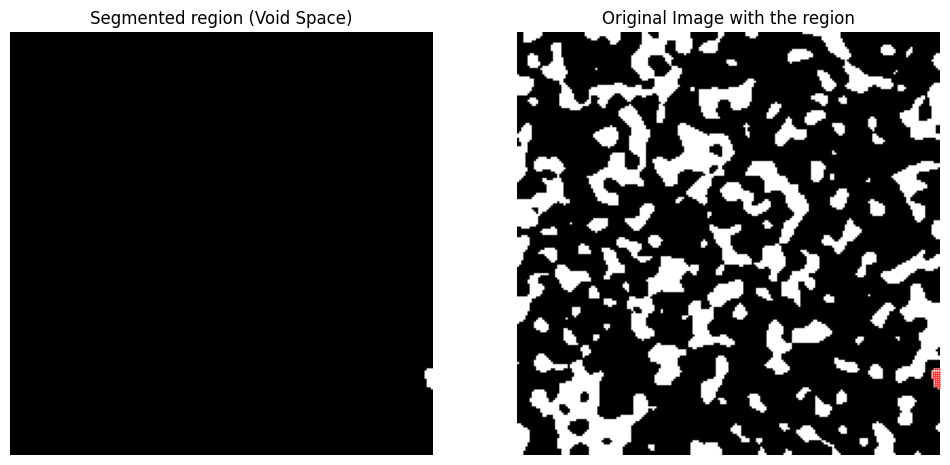

In [85]:
# Lista para salvar as regiões segmentadas (void space)
regioes_segmentadas = []

# Lista para salvar as coordenadas de cada região
coordenadas_poros = []

# Iterar sobre os diferentes rótulos de regiões na imagem rotulada
for label in range(1, num_labels + 1):
    # Encontrar os índices dos pixels da região na imagem rotulada
    indices_regiao = np.where(labeled_image == label)

    # Salvar as coordenadas x e y dos pixels da região na imagem original
    coords_x, coords_y = indices_regiao[1], indices_regiao[0]
    coordenadas_poros.append((coords_x, coords_y))

    # Extrair a região segmentada (void space) da imagem original
    regiao_segmentada = np.zeros_like(im)
    regiao_segmentada[coords_y, coords_x] = 1  # Atribuir 1 aos pixels da região
    regioes_segmentadas.append(regiao_segmentada)

import random
random_number = random.randint(0, len(regioes_segmentadas))  # Generates a random integer between 1 and 100 (inclusive)
print("Random number:", random_number)

# Exemplo de acesso a uma região segmentada e suas coordenadas
indice_da_regiao = random_number  # Índice da região desejada
regiao_segmentada_desejada = regioes_segmentadas[indice_da_regiao]
coordenadas_da_regiao_desejada = coordenadas_poros[indice_da_regiao]



# Visualizar a região segmentada e as coordenadas
plt.figure(figsize=(12, 6))
plt.subplot(121)
plt.imshow(regiao_segmentada_desejada, cmap='gray')
plt.title('Segmented region (Void Space)')
plt.axis('off')

plt.subplot(122)
plt.imshow(binary_image, cmap='gray')
plt.plot(coordenadas_da_regiao_desejada[0], coordenadas_da_regiao_desejada[1], 'r.', markersize=1)
plt.title('Original Image with the region')
plt.axis('off')

plt.show()

In [86]:
# The number of pixels to consider a pore
pore_number = 30

In [87]:
distancia_maxima= pore_number * 0.30
distancia_maxima

9.0

In [165]:
import numpy as np
from sklearn.cluster import KMeans
from skimage.measure import find_contours

def apply_kmeans_to_region(region_segmentada, pore_number):
    # Obter os pixels que são representados por 1 na região segmentada
    pixels_0 = np.argwhere(region_segmentada == 1)

    # Determinar o número de vezes que len(pixels_0) excede pore_number
    excessos = len(pixels_0) // pore_number

    # Ajustar o número de clusters com base nos excessos
    num_clusters = max(1, excessos)

    # Aplicar K-means aos pixels 0 para segmentá-los em clusters
    kmeans = KMeans(n_clusters=num_clusters, random_state=42)
    kmeans.fit(pixels_0)

    # Obter os rótulos dos clusters atribuídos aos pixels 0
    labels = kmeans.labels_

    # Criar uma matriz com os rótulos dos clusters nas posições dos pixels 0
    clustered_region = np.zeros_like(region_segmentada)
    for label, pixel in zip(labels, pixels_0):
        clustered_region[pixel[0], pixel[1]] = label + 1  # Adicionar 1 para evitar label 0

    # Calcular os centros dos clusters
    cluster_centers = kmeans.cluster_centers_

    # Encontrar os contornos de cada cluster
    contornos_por_cluster = []
    for i in range(num_clusters):
        mask = clustered_region == (i + 1)  # Criar uma máscara para o cluster atual
        contornos = find_contours(mask, 0.5)  # Encontrar os contornos do cluster atual
        contornos_por_cluster.append(contornos)

    # Retornar a região clusterizada, o número de clusters, as coordenadas dos centros dos clusters e os contornos de cada cluster
    return clustered_region, num_clusters, cluster_centers, contornos_por_cluster



import numpy as np
from skimage.measure import label, regionprops

def calculate_aspect_ratios(clustered_region):
    # Rotular a imagem para obter clusters individuais
    labeled_image = label(clustered_region)
    regions = regionprops(labeled_image)

    aspect_ratios = []
    for region in regions:
        major_axis_length = region.major_axis_length
        minor_axis_length = region.minor_axis_length

        #print(f"Major axis length: {major_axis_length}, Minor axis length: {minor_axis_length}")  # Informações para depuração

        if major_axis_length > 0:  # Evitar divisão por zero
            aspect_ratio = minor_axis_length / major_axis_length
        else:
            aspect_ratio = 0
        aspect_ratios.append(aspect_ratio)

    return aspect_ratios


def calculate_areas(clustered_region):
    # Rotular a imagem para obter clusters individuais
    labeled_image = label(clustered_region)
    regions = regionprops(labeled_image)

    #aspect_ratios = []
    areas = []
    for region in regions:
        ##major_axis_length = region.major_axis_length
        ##minor_axis_length = region.minor_axis_length
        area = region.area

        # Calcular a razão de aspecto
        ##if major_axis_length > 0:  # Evitar divisão por zero
        ##    aspect_ratio = minor_axis_length / major_axis_length
        ##else:
        ##    aspect_ratio = 0
        
        ##aspect_ratios.append(aspect_ratio)
        areas.append(area)

    return areas

# Exemplo de uso
# region_segmentada deve ser a sua matriz de região segmentada
# clustered_region, _, _ = apply_kmeans_to_region(region_segmentada, pore_number)
# aspect_ratios = calculate_aspect_ratios(clustered_region)
# print(aspect_ratios)





# Lista para armazenar as coordenadas dos centros de cada região clusterizada
coordenadas_centros_kmeans = []
resultados_kmeans = []
number_of_pores_kmeans = []
ratio_of_aspect_cluster_kmeans = []
areas_cluster_kmeans = []
contour_per_cluster = []

# Plotar as regiões segmentadas após a aplicação do K-means
for i, region_segmentada in enumerate(regioes_segmentadas, start=1):
    # Aplicar o K-means à região segmentada atual
    clustered_region_kmeans, n_por_kmeans, centros_kmeans, contour_k_means = apply_kmeans_to_region(region_segmentada, pore_number)

    # Armazenar as coordenadas dos centros dos clusters na lista
    coordenadas_centros_kmeans.append(centros_kmeans)
    resultados_kmeans.append(clustered_region_kmeans)
    number_of_pores_kmeans.append(n_por_kmeans)
    # Calcular as razões de aspecto dos clusters
    aspect_ratios_kmeans = calculate_aspect_ratios(clustered_region_kmeans)
    areas_kmeans = calculate_areas(clustered_region_kmeans)
    ratio_of_aspect_cluster_kmeans.append(aspect_ratios_kmeans)
    areas_cluster_kmeans.append(areas_kmeans)
    contour_per_cluster.append(contour_k_means)

In [166]:
len(resultados_kmeans), len(contour_per_cluster)

(122, 122)

In [167]:
contour_per_cluster[1],resultados_kmeans[1]

([[array([[ 0. , 40.5],
          [ 1. , 40.5],
          [ 1.5, 40. ],
          [ 1.5, 39. ],
          [ 2. , 38.5],
          [ 2.5, 38. ],
          [ 3. , 37.5],
          [ 3.5, 37. ],
          [ 3.5, 36. ],
          [ 3.5, 35. ],
          [ 3. , 34.5],
          [ 2.5, 34. ],
          [ 2.5, 33. ],
          [ 2. , 32.5],
          [ 1.5, 32. ],
          [ 1. , 31.5],
          [ 0. , 31.5]])],
  [array([[ 0. , 48.5],
          [ 1. , 48.5],
          [ 2. , 48.5],
          [ 3. , 48.5],
          [ 3.5, 48. ],
          [ 4. , 47.5],
          [ 4.5, 47. ],
          [ 5. , 46.5],
          [ 5.5, 46. ],
          [ 5.5, 45. ],
          [ 5.5, 44. ],
          [ 5. , 43.5],
          [ 4. , 43.5],
          [ 3.5, 43. ],
          [ 3. , 42.5],
          [ 2.5, 42. ],
          [ 2. , 41.5],
          [ 1.5, 41. ],
          [ 1. , 40.5],
          [ 0. , 40.5]])]],
 array([[0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
        [0, 0, 0, ..., 0, 0, 0],
      

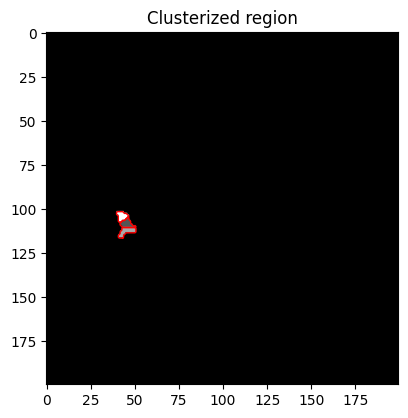

In [235]:
import random
import numpy as np
import matplotlib.pyplot as plt
from skimage.measure import label, find_contours

# Função para rotular clusters e encontrar seus contornos
def obter_contornos_dos_clusters(resultados_kmeans):
    contornos_por_regiao = []

    for regiao_clusterizada in resultados_kmeans:
        # Rotular cada cluster na região
        labeled_clusters = label(regiao_clusterizada)
        num_clusters = labeled_clusters.max()
        
        # Lista para armazenar contornos dos clusters na região atual
        contornos_da_regiao = []
        
        for cluster_num in range(1, num_clusters + 1):
            # Obter uma máscara do cluster atual
            mask = (labeled_clusters == cluster_num)
            # Encontrar contornos do cluster atual
            contornos = find_contours(mask, 0.5)
            contornos_da_regiao.append(contornos)
        
        contornos_por_regiao.append(contornos_da_regiao)

    return contornos_por_regiao

# Comprimento da lista resultados_kmeans
length = len(resultados_kmeans)

# Obter os contornos de todos os clusters em todas as regiões clusterizadas
contornos_por_regiao = obter_contornos_dos_clusters(resultados_kmeans)

# Gerar um índice aleatório para escolher uma região clusterizada
#random_index = random.randint(0, length - 1)

# Obter contornos da região clusterizada aleatória
contornos_aleatorios = contornos_por_regiao[random_index]

# Inicializar uma figura
plt.figure(figsize=(10, 10))

# Plotar a região clusterizada aleatória
plt.subplot(121)
plt.imshow(resultados_kmeans[random_index], cmap='gray')
plt.title('Clusterized region')

# Plotar os contornos dos clusters na região clusterizada aleatória
for contorno_cluster in contornos_aleatorios:
    for contorno in contorno_cluster:
        plt.plot(contorno[:, 1], contorno[:, 0], 'r-', linewidth=1)  # 'r-' para uma linha vermelha

# Mostrar o gráfico
plt.show()


Número de ligações: 18


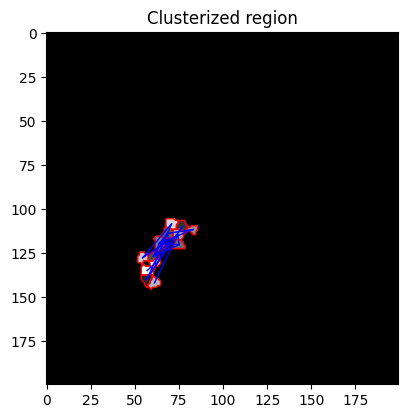

In [239]:
import random
import numpy as np
import matplotlib.pyplot as plt
from skimage.measure import label, find_contours
from scipy.spatial.distance import cdist

# Função para rotular clusters e encontrar seus contornos
def obter_contornos_dos_clusters(resultados_kmeans):
    contornos_por_regiao = []

    for regiao_clusterizada in resultados_kmeans:
        # Rotular cada cluster na região
        labeled_clusters = label(regiao_clusterizada)
        num_clusters = labeled_clusters.max()
        
        # Lista para armazenar contornos dos clusters na região atual
        contornos_da_regiao = []
        
        for cluster_num in range(1, num_clusters + 1):
            # Obter uma máscara do cluster atual
            mask = (labeled_clusters == cluster_num)
            # Encontrar contornos do cluster atual
            contornos = find_contours(mask, 0.5)
            contornos_da_regiao.append(contornos)
        
        contornos_por_regiao.append(contornos_da_regiao)

    return contornos_por_regiao

# Função para calcular a distância mínima entre dois contornos
def distancia_minima_entre_contornos(contorno1, contorno2):
    pontos_contorno1 = np.vstack(contorno1)
    pontos_contorno2 = np.vstack(contorno2)
    distancias = cdist(pontos_contorno1, pontos_contorno2)
    return distancias.min()

# Comprimento da lista resultados_kmeans
length = len(resultados_kmeans)

# Obter os contornos de todos os clusters em todas as regiões clusterizadas
contornos_por_regiao = obter_contornos_dos_clusters(resultados_kmeans)

# Gerar um índice aleatório para escolher uma região clusterizada
random_index = random.randint(0, length - 1)

# Obter contornos e centros da região clusterizada aleatória
contornos_aleatorios = contornos_por_regiao[random_index]
centros_aleatorios = coordenadas_centros_kmeans[random_index]

# Inicializar uma figura
plt.figure(figsize=(10, 10))

# Plotar a região clusterizada aleatória
plt.subplot(121)
plt.imshow(resultados_kmeans[random_index], cmap='gray')
plt.title('Clusterized region')

# Plotar os contornos dos clusters na região clusterizada aleatória
for contorno_cluster in contornos_aleatorios:
    for contorno in contorno_cluster:
        plt.plot(contorno[:, 1], contorno[:, 0], 'r-', linewidth=1)  # 'r-' para uma linha vermelha

# Inicialize uma variável para contar o número de ligações
numero_de_ligacoes = 0

# Ligar centros de clusters cujos contornos têm distância zero
for i in range(len(centros_aleatorios)):
    for j in range(i + 1, len(centros_aleatorios)):
        min_dist = distancia_minima_entre_contornos(contornos_aleatorios[i], contornos_aleatorios[j])
        if min_dist == 0:
            plt.plot([centros_aleatorios[i][1], centros_aleatorios[j][1]], 
                     [centros_aleatorios[i][0], centros_aleatorios[j][0]], 'b-', linewidth=1)
            numero_de_ligacoes += 1

# Exibir o número de ligações
print("Número de ligações:", numero_de_ligacoes)

# Mostrar o gráfico
plt.show()

Número de ligações: 0


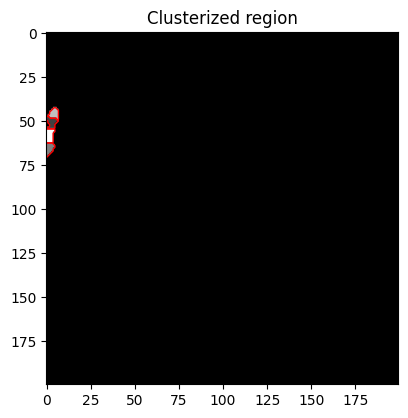

In [221]:
import random
import numpy as np
import matplotlib.pyplot as plt
from skimage.measure import label, find_contours
from scipy.spatial.distance import cdist

# Função para rotular clusters e encontrar seus contornos
def obter_contornos_dos_clusters(resultados_kmeans):
    contornos_por_regiao = []

    for regiao_clusterizada in resultados_kmeans:
        # Rotular cada cluster na região
        labeled_clusters = label(regiao_clusterizada)
        num_clusters = labeled_clusters.max()
        
        # Lista para armazenar contornos dos clusters na região atual
        contornos_da_regiao = []
        
        for cluster_num in range(1, num_clusters + 1):
            # Obter uma máscara do cluster atual
            mask = (labeled_clusters == cluster_num)
            # Encontrar contornos do cluster atual
            contornos = find_contours(mask, 0.5)
            contornos_da_regiao.append(contornos)
        
        contornos_por_regiao.append(contornos_da_regiao)

    return contornos_por_regiao

# Função para calcular a distância mínima entre dois contornos
def distancia_minima_entre_contornos(contorno1, contorno2):
    pontos_contorno1 = np.vstack(contorno1)
    pontos_contorno2 = np.vstack(contorno2)
    distancias = cdist(pontos_contorno1, pontos_contorno2)
    return distancias.min()

# Função para calcular a distância do centro ao contorno
def distancia_centro_ao_contorno(centro, contorno):
    distancias = cdist([centro], contorno)
    return distancias.min()

# Função para verificar se os clusters estão próximos
def clusters_proximos(centro1, centro2, distancia_minima):
    dist_entre_centros = np.linalg.norm(np.array(centro1) - np.array(centro2))
    return dist_entre_centros <= distancia_minima

# Comprimento da lista resultados_kmeans
length = len(resultados_kmeans)

# Obter os contornos de todos os clusters em todas as regiões clusterizadas
contornos_por_regiao = obter_contornos_dos_clusters(resultados_kmeans)

# Gerar um índice aleatório para escolher uma região clusterizada
random_index = random.randint(0, length - 1)

# Obter contornos e centros da região clusterizada aleatória
contornos_aleatorios = contornos_por_regiao[random_index]
centros_aleatorios = coordenadas_centros_kmeans[random_index]
imagem_aleatoria = resultados_kmeans[random_index]

# Definir a distância mínima para ligar os clusters
distancia_minima_ligacao = 0  # Por exemplo, 50 pixels

# Inicializar uma figura
plt.figure(figsize=(10, 10))

# Plotar a região clusterizada aleatória
plt.subplot(121)
plt.imshow(imagem_aleatoria, cmap='gray')
plt.title('Clusterized region')

# Plotar os contornos dos clusters na região clusterizada aleatória
for contorno_cluster in contornos_aleatorios:
    for contorno in contorno_cluster:
        plt.plot(contorno[:, 1], contorno[:, 0], 'r-', linewidth=1)  # 'r-' para uma linha vermelha

# Inicialize uma variável para contar o número de ligações
numero_de_ligacoes = 0

# Ligar os clusters que atendem aos critérios
for i in range(len(centros_aleatorios)):
    for j in range(i + 1, len(centros_aleatorios)):
        min_dist = distancia_minima_entre_contornos(contornos_aleatorios[i], contornos_aleatorios[j])
        if min_dist == 0 and clusters_proximos(centros_aleatorios[i], centros_aleatorios[j], distancia_minima_ligacao):
            plt.plot([centros_aleatorios[i][1], centros_aleatorios[j][1]], 
                     [centros_aleatorios[i][0], centros_aleatorios[j][0]], 'b-', linewidth=1)
            numero_de_ligacoes += 1

# Exibir o número de ligações
print("Número de ligações:", numero_de_ligacoes)

# Mostrar o gráfico
plt.show()

TypeError: list indices must be integers or slices, not tuple

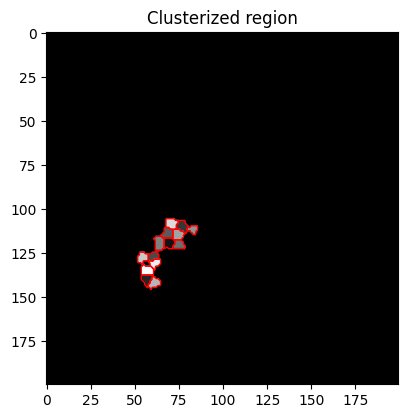

In [176]:
import random
import numpy as np
import matplotlib.pyplot as plt
from skimage.measure import label, find_contours
from scipy.spatial.distance import cdist

# Função para rotular clusters e encontrar seus contornos
def obter_contornos_dos_clusters(resultados_kmeans):
    contornos_por_regiao = []

    for regiao_clusterizada in resultados_kmeans:
        # Rotular cada cluster na região
        labeled_clusters = label(regiao_clusterizada)
        num_clusters = labeled_clusters.max()
        
        # Lista para armazenar contornos dos clusters na região atual
        contornos_da_regiao = []
        
        for cluster_num in range(1, num_clusters + 1):
            # Obter uma máscara do cluster atual
            mask = (labeled_clusters == cluster_num)
            # Encontrar contornos do cluster atual
            contornos = find_contours(mask, 0.5)
            contornos_da_regiao.append(contornos)
        
        contornos_por_regiao.append(contornos_da_regiao)

    return contornos_por_regiao

# Função para calcular a distância mínima entre dois contornos
def distancia_minima_entre_contornos(contorno1, contorno2):
    pontos_contorno1 = np.vstack(contorno1)
    pontos_contorno2 = np.vstack(contorno2)
    distancias = cdist(pontos_contorno1, pontos_contorno2)
    return distancias.min()

# Função para verificar se duas regiões vizinhas são diferentes
def regioes_vizinhas_diferentes(resultados_kmeans, centro1, centro2):
    # Obter os índices dos centros
    indice_centro1 = tuple(map(int, centro1))
    indice_centro2 = tuple(map(int, centro2))
    
    # Obter as regiões vizinhas dos centros
    vizinhos_centro1 = resultados_kmeans[indice_centro1[0]-1:indice_centro1[0]+2,
                                          indice_centro1[1]-1:indice_centro1[1]+2]
    vizinhos_centro2 = resultados_kmeans[indice_centro2[0]-1:indice_centro2[0]+2,
                                          indice_centro2[1]-1:indice_centro2[1]+2]
    
    # Verificar se as regiões vizinhas são diferentes
    return np.any(vizinhos_centro1 != vizinhos_centro2)

# Comprimento da lista resultados_kmeans
length = len(resultados_kmeans)

# Obter os contornos de todos os clusters em todas as regiões clusterizadas
contornos_por_regiao = obter_contornos_dos_clusters(resultados_kmeans)

# Gerar um índice aleatório para escolher uma região clusterizada
random_index = random.randint(0, length - 1)

# Obter contornos e centros da região clusterizada aleatória
contornos_aleatorios = contornos_por_regiao[random_index]
centros_aleatorios = coordenadas_centros_kmeans[random_index]

# Inicializar uma figura
plt.figure(figsize=(10, 10))

# Plotar a região clusterizada aleatória
plt.subplot(121)
plt.imshow(resultados_kmeans[random_index], cmap='gray')
plt.title('Clusterized region')

# Plotar os contornos dos clusters na região clusterizada aleatória
for contorno_cluster in contornos_aleatorios:
    for contorno in contorno_cluster:
        plt.plot(contorno[:, 1], contorno[:, 0], 'r-', linewidth=1)  # 'r-' para uma linha vermelha

# Inicialize uma variável para contar o número de ligações
numero_de_ligacoes = 0

# Ligar centros de clusters cujos contornos têm distância zero e as regiões são adjacentes
for i in range(len(centros_aleatorios)):
    for j in range(i + 1, len(centros_aleatorios)):
        min_dist = distancia_minima_entre_contornos(contornos_aleatorios[i], contornos_aleatorios[j])
        if min_dist == 0 and regioes_vizinhas_diferentes(resultados_kmeans, centros_aleatorios[i], centros_aleatorios[j]):
            plt.plot([centros_aleatorios[i][1], centros_aleatorios[j][1]], 
                     [centros_aleatorios[i][0], centros_aleatorios[j][0]], 'b-', linewidth=1)
            numero_de_ligacoes += 1

# Exibir o número de ligações
print("Número de ligações:", numero_de_ligacoes)

# Mostrar o gráfico
plt.show()


TypeError: 'numpy.float64' object cannot be interpreted as an integer

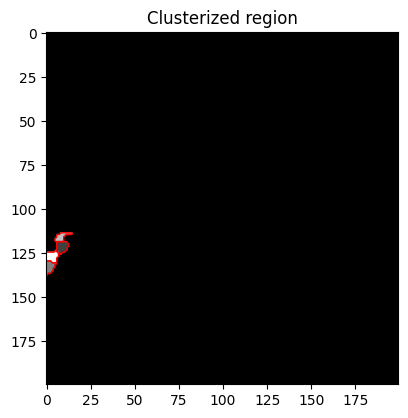

In [100]:
import random
import numpy as np
import matplotlib.pyplot as plt
from skimage.measure import label, find_contours
from scipy.spatial.distance import cdist
from skimage.draw import line

# Função para rotular clusters e encontrar seus contornos
def obter_contornos_dos_clusters(resultados_kmeans):
    contornos_por_regiao = []

    for regiao_clusterizada in resultados_kmeans:
        # Rotular cada cluster na região
        labeled_clusters = label(regiao_clusterizada)
        num_clusters = labeled_clusters.max()
        
        # Lista para armazenar contornos dos clusters na região atual
        contornos_da_regiao = []
        
        for cluster_num in range(1, num_clusters + 1):
            # Obter uma máscara do cluster atual
            mask = (labeled_clusters == cluster_num)
            # Encontrar contornos do cluster atual
            contornos = find_contours(mask, 0.5)
            contornos_da_regiao.append(contornos)
        
        contornos_por_regiao.append(contornos_da_regiao)

    return contornos_por_regiao

# Função para calcular a distância mínima entre dois contornos
def distancia_minima_entre_contornos(contorno1, contorno2):
    pontos_contorno1 = np.vstack(contorno1)
    pontos_contorno2 = np.vstack(contorno2)
    distancias = cdist(pontos_contorno1, pontos_contorno2)
    return distancias.min()

# Função para verificar se a linha entre dois centros passa apenas por regiões clusterizadas
def linha_em_regiao_clusterizada(imagem, centro1, centro2):
    rr, cc = line(centro1[0], centro1[1], centro2[0], centro2[1])
    return np.all(imagem[rr, cc] > 0)

# Comprimento da lista resultados_kmeans
length = len(resultados_kmeans)

# Obter os contornos de todos os clusters em todas as regiões clusterizadas
contornos_por_regiao = obter_contornos_dos_clusters(resultados_kmeans)

# Gerar um índice aleatório para escolher uma região clusterizada
random_index = random.randint(0, length - 1)

# Obter contornos e centros da região clusterizada aleatória
contornos_aleatorios = contornos_por_regiao[random_index]
centros_aleatorios = coordenadas_centros_kmeans[random_index]
imagem_aleatoria = resultados_kmeans[random_index]

# Inicializar uma figura
plt.figure(figsize=(10, 10))

# Plotar a região clusterizada aleatória
plt.subplot(121)
plt.imshow(imagem_aleatoria, cmap='gray')
plt.title('Clusterized region')

# Plotar os contornos dos clusters na região clusterizada aleatória
for contorno_cluster in contornos_aleatorios:
    for contorno in contorno_cluster:
        plt.plot(contorno[:, 1], contorno[:, 0], 'r-', linewidth=1)  # 'r-' para uma linha vermelha

# Inicialize uma variável para contar o número de ligações
numero_de_ligacoes = 0

# Ligar centros de clusters cujos contornos têm distância zero e a linha passa por regiões clusterizadas
for i in range(len(centros_aleatorios)):
    for j in range(i + 1, len(centros_aleatorios)):
        min_dist = distancia_minima_entre_contornos(contornos_aleatorios[i], contornos_aleatorios[j])
        if min_dist == 0 and linha_em_regiao_clusterizada(imagem_aleatoria, centros_aleatorios[i], centros_aleatorios[j]):
            plt.plot([centros_aleatorios[i][1], centros_aleatorios[j][1]], 
                     [centros_aleatorios[i][0], centros_aleatorios[j][0]], 'b-', linewidth=1)
            numero_de_ligacoes += 1

# Exibir o número de ligações
print("Número de ligações:", numero_de_ligacoes)

# Mostrar o gráfico
plt.show()


Número de ligações: 0


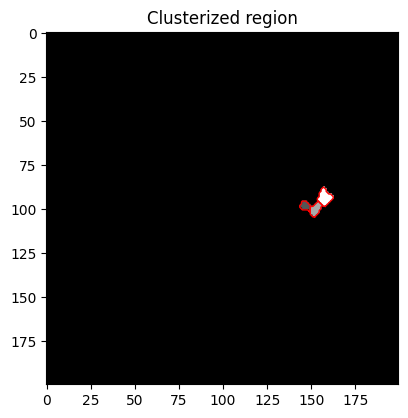

In [162]:
import random
import numpy as np
import matplotlib.pyplot as plt
from skimage.measure import find_contours
from scipy.spatial.distance import cdist
from collections import deque

# Function to label clusters and find their contours
def label_clusters_and_find_contours(resultados_kmeans):
    contornos_por_regiao = []

    for regiao_clusterizada in resultados_kmeans:
        contornos_da_regiao = []
        contornos = find_contours(regiao_clusterizada, 0.5)
        contornos_da_regiao.extend(contornos)
        
        contornos_por_regiao.append(contornos_da_regiao)

    return contornos_por_regiao

# Function to calculate the minimum distance between two contours
def min_distance_between_contours(contorno1, contorno2):
    pontos_contorno1 = np.vstack(contorno1)
    pontos_contorno2 = np.vstack(contorno2)
    distancias = cdist(pontos_contorno1, pontos_contorno2)
    return distancias.min()

# Function to check if two clusters are adjacent based on the distance between their edges
def are_adjacent(contorno1, contorno2, limite_distancia):
    distancia_minima = min_distance_between_contours(contorno1, contorno2)
    return distancia_minima <= limite_distancia

# Function to create the graph of clusters
def create_clusters_graph(contornos_por_regiao, limite_distancia):
    grafo_clusters = {}
    for i, contornos_regiao in enumerate(contornos_por_regiao):
        grafo_clusters[i] = set()
        for j, contornos_outra_regiao in enumerate(contornos_por_regiao):
            if i != j and any(are_adjacent(c1, c2, limite_distancia) for c1 in contornos_regiao for c2 in contornos_outra_regiao):
                grafo_clusters[i].add(j)
    return grafo_clusters

# Function to perform BFS on the graph
def bfs(start, end, graph):
    queue = deque([(start, [start])])
    while queue:
        (node, path) = queue.popleft()
        for neighbor in graph[node] - set(path):
            if neighbor == end:
                yield path + [neighbor]
            else:
                queue.append((neighbor, path + [neighbor]))

# Generate random clusters
resultados_kmeans = [np.random.randint(0, 2, (100, 100)) for _ in range(5)]

# Get the contours of all clusters in all clusterized regions
contornos_por_regiao = label_clusters_and_find_contours(resultados_kmeans)

# Initialize the graph of clusters
grafo_clusters = create_clusters_graph(contornos_por_regiao, limite_distancia=10)  # Set the limit as needed

# Select two random clusters to find the path between them
cluster1 = random.choice(list(grafo_clusters.keys()))
cluster2 = random.choice(list(grafo_clusters.keys()))

# Find the path between the two clusters using BFS
paths = list(bfs(cluster1, cluster2, grafo_clusters))

# Plot the clusters
plt.figure(figsize=(12, 6))

# Plot each cluster
for i, contornos in enumerate(contornos_por_regiao):
    for contorno in contornos:
        plt.plot(contorno[:, 1], contorno[:, 0], 'r-', linewidth=1)

# Plot the path between the two clusters
for path in paths:
    for i in range(len(path) - 1):
        plt.plot([np.mean(contornos_por_regiao[path[i]][0][:, 1]), np.mean(contornos_por_regiao[path[i + 1]][0][:, 1])],
                 [np.mean(contornos_por_regiao[path[i]][0][:, 0]), np.mean(contornos_por_regiao[path[i + 1]][0][:, 0])],
                 'b-', linewidth=2)

# Highlight the start and end clusters
plt.scatter(np.mean(contornos_por_regiao[cluster1][0][:, 1]), np.mean(contornos_por_regiao[cluster1][0][:, 0]), color='g', marker='o', s=100, label='Start')
plt.scatter(np.mean(contornos_por_regiao[cluster2][0][:, 1]), np.mean(contornos_por_regiao[cluster2][0][:, 0]), color='m', marker='o', s=100, label='End')

plt.title('Clusters and Paths between Clusters')
plt.legend()
plt.gca().invert_yaxis()
plt.show()


TypeError: 'numpy.float64' object cannot be interpreted as an integer

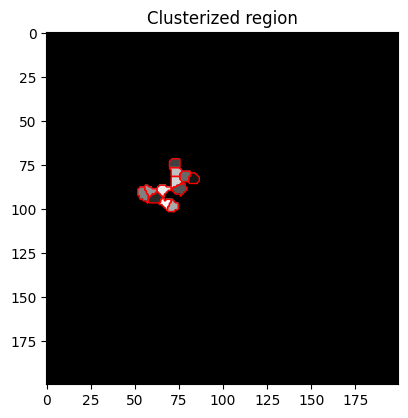

Número de ligações: 5


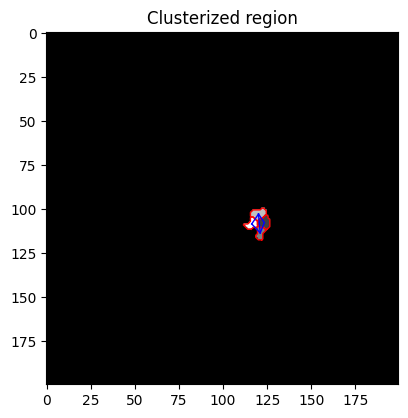

In [104]:
import random
import numpy as np
import matplotlib.pyplot as plt
from skimage.measure import label, find_contours
from scipy.spatial.distance import cdist
from skimage.draw import line

# Função para rotular clusters e encontrar seus contornos
def obter_contornos_dos_clusters(resultados_kmeans):
    contornos_por_regiao = []

    for regiao_clusterizada in resultados_kmeans:
        # Rotular cada cluster na região
        labeled_clusters = label(regiao_clusterizada)
        num_clusters = labeled_clusters.max()
        
        # Lista para armazenar contornos dos clusters na região atual
        contornos_da_regiao = []
        
        for cluster_num in range(1, num_clusters + 1):
            # Obter uma máscara do cluster atual
            mask = (labeled_clusters == cluster_num)
            # Encontrar contornos do cluster atual
            contornos = find_contours(mask, 0.5)
            contornos_da_regiao.append(contornos)
        
        contornos_por_regiao.append(contornos_da_regiao)

    return contornos_por_regiao

# Função para calcular a distância mínima entre dois contornos
def distancia_minima_entre_contornos(contorno1, contorno2):
    pontos_contorno1 = np.vstack(contorno1)
    pontos_contorno2 = np.vstack(contorno2)
    distancias = cdist(pontos_contorno1, pontos_contorno2)
    return distancias.min()

# Função para verificar se a linha entre dois centros passa apenas por regiões clusterizadas
def linha_em_regiao_clusterizada(imagem, centro1, centro2):
    rr, cc = line(int(centro1[0]), int(centro1[1]), int(centro2[0]), int(centro2[1]))
    return np.all(imagem[rr, cc] > 0)

# Comprimento da lista resultados_kmeans
length = len(resultados_kmeans)

# Obter os contornos de todos os clusters em todas as regiões clusterizadas
contornos_por_regiao = obter_contornos_dos_clusters(resultados_kmeans)

# Gerar um índice aleatório para escolher uma região clusterizada
random_index = random.randint(0, length - 1)

# Obter contornos e centros da região clusterizada aleatória
contornos_aleatorios = contornos_por_regiao[random_index]
centros_aleatorios = coordenadas_centros_kmeans[random_index]
imagem_aleatoria = resultados_kmeans[random_index]

# Inicializar uma figura
plt.figure(figsize=(10, 10))

# Plotar a região clusterizada aleatória
plt.subplot(121)
plt.imshow(imagem_aleatoria, cmap='gray')
plt.title('Clusterized region')

# Plotar os contornos dos clusters na região clusterizada aleatória
for contorno_cluster in contornos_aleatorios:
    for contorno in contorno_cluster:
        plt.plot(contorno[:, 1], contorno[:, 0], 'r-', linewidth=1)  # 'r-' para uma linha vermelha

# Inicialize uma variável para contar o número de ligações
numero_de_ligacoes = 0

# Ligar centros de clusters cujos contornos têm distância zero e a linha passa por regiões clusterizadas
for i in range(len(centros_aleatorios)):
    for j in range(i + 1, len(centros_aleatorios)):
        min_dist = distancia_minima_entre_contornos(contornos_aleatorios[i], contornos_aleatorios[j])
        if min_dist == 0 and linha_em_regiao_clusterizada(imagem_aleatoria, centros_aleatorios[i], centros_aleatorios[j]):
            plt.plot([centros_aleatorios[i][1], centros_aleatorios[j][1]], 
                     [centros_aleatorios[i][0], centros_aleatorios[j][0]], 'b-', linewidth=1)
            numero_de_ligacoes += 1

# Exibir o número de ligações
print("Número de ligações:", numero_de_ligacoes)

# Mostrar o gráfico
plt.show()


Número de ligações: 14


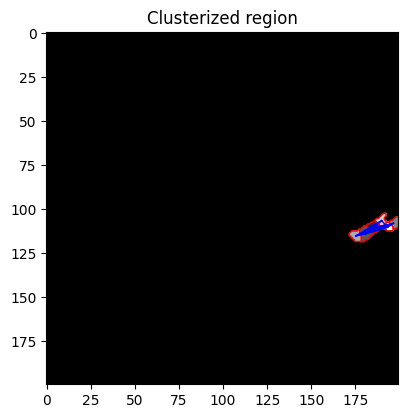

In [115]:
import random
import numpy as np
import matplotlib.pyplot as plt
from skimage.measure import label, find_contours
from scipy.spatial.distance import cdist
from skimage.draw import line

# Função para rotular clusters e encontrar seus contornos
def obter_contornos_dos_clusters(resultados_kmeans):
    contornos_por_regiao = []

    for regiao_clusterizada in resultados_kmeans:
        # Rotular cada cluster na região
        labeled_clusters = label(regiao_clusterizada)
        num_clusters = labeled_clusters.max()
        
        # Lista para armazenar contornos dos clusters na região atual
        contornos_da_regiao = []
        
        for cluster_num in range(1, num_clusters + 1):
            # Obter uma máscara do cluster atual
            mask = (labeled_clusters == cluster_num)
            # Encontrar contornos do cluster atual
            contornos = find_contours(mask, 0.5)
            contornos_da_regiao.append(contornos)
        
        contornos_por_regiao.append(contornos_da_regiao)

    return contornos_por_regiao

# Função para calcular a distância mínima entre dois contornos
def distancia_minima_entre_contornos(contorno1, contorno2):
    pontos_contorno1 = np.vstack(contorno1)
    pontos_contorno2 = np.vstack(contorno2)
    distancias = cdist(pontos_contorno1, pontos_contorno2)
    return distancias.min()

# Função para verificar se a linha entre dois pontos passa apenas por regiões clusterizadas
def linha_em_regiao_clusterizada(imagem, ponto1, ponto2):
    rr, cc = line(int(ponto1[0]), int(ponto1[1]), int(ponto2[0]), int(ponto2[1]))
    return np.all(imagem[rr, cc] > 0)

# Comprimento da lista resultados_kmeans
length = len(resultados_kmeans)

# Obter os contornos de todos os clusters em todas as regiões clusterizadas
contornos_por_regiao = obter_contornos_dos_clusters(resultados_kmeans)

# Gerar um índice aleatório para escolher uma região clusterizada
random_index = random.randint(0, length - 1)

# Obter contornos e centros da região clusterizada aleatória
contornos_aleatorios = contornos_por_regiao[random_index]
imagem_aleatoria = resultados_kmeans[random_index]

# Inicializar uma figura
plt.figure(figsize=(10, 10))

# Plotar a região clusterizada aleatória
plt.subplot(121)
plt.imshow(imagem_aleatoria, cmap='gray')
plt.title('Clusterized region')

# Plotar os contornos dos clusters na região clusterizada aleatória
for contorno_cluster in contornos_aleatorios:
    for contorno in contorno_cluster:
        plt.plot(contorno[:, 1], contorno[:, 0], 'r-', linewidth=1)  # 'r-' para uma linha vermelha

# Inicialize uma variável para contar o número de ligações
numero_de_ligacoes = 0

# Ligar os pontos médios dos contornos cujas linhas passam apenas por regiões clusterizadas
for i in range(len(contornos_aleatorios)):
    for j in range(i + 1, len(contornos_aleatorios)):
        ponto_medio1 = np.mean(contornos_aleatorios[i][0], axis=0)
        ponto_medio2 = np.mean(contornos_aleatorios[j][0], axis=0)
        if linha_em_regiao_clusterizada(imagem_aleatoria, ponto_medio1, ponto_medio2):
            plt.plot([ponto_medio1[1], ponto_medio2[1]], 
                     [ponto_medio1[0], ponto_medio2[0]], 'b-', linewidth=1)
            numero_de_ligacoes += 1

# Exibir o número de ligações}
print("Número de ligações:", numero_de_ligacoes)

# Mostrar o gráfico
plt.show()


Número de ligações: 1


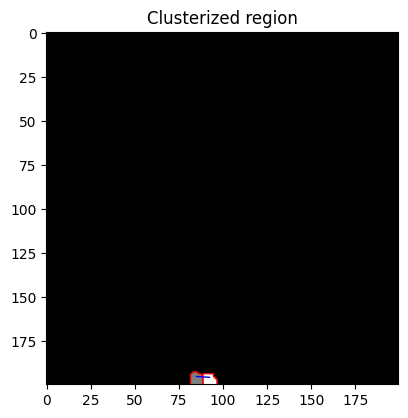

In [154]:
# almost Code sucess
import random
import numpy as np
import matplotlib.pyplot as plt
from skimage.measure import label, find_contours
from scipy.spatial.distance import cdist
from skimage.draw import line

# Função para rotular clusters e encontrar seus contornos
def obter_contornos_dos_clusters(resultados_kmeans):
    contornos_por_regiao = []

    for regiao_clusterizada in resultados_kmeans:
        # Rotular cada cluster na região
        labeled_clusters = label(regiao_clusterizada)
        num_clusters = labeled_clusters.max()
        
        # Lista para armazenar contornos dos clusters na região atual
        contornos_da_regiao = []
        
        for cluster_num in range(1, num_clusters + 1):
            # Obter uma máscara do cluster atual
            mask = (labeled_clusters == cluster_num)
            # Encontrar contornos do cluster atual
            contornos = find_contours(mask, 0.5)
            contornos_da_regiao.append(contornos)
        
        contornos_por_regiao.append(contornos_da_regiao)

    return contornos_por_regiao

# Função para calcular a distância mínima entre dois contornos
def distancia_minima_entre_contornos(contorno1, contorno2):
    pontos_contorno1 = np.vstack(contorno1)
    pontos_contorno2 = np.vstack(contorno2)
    distancias = cdist(pontos_contorno1, pontos_contorno2)
    return distancias.min()

# Função para verificar se a linha entre dois pontos passa apenas por regiões clusterizadas
def linha_em_regiao_clusterizada(imagem, ponto1, ponto2):
    rr, cc = line(int(ponto1[0]), int(ponto1[1]), int(ponto2[0]), int(ponto2[1]))
    return np.all(imagem[rr, cc] > 0)

# Função para calcular a distância entre dois pontos
def distancia_entre_pontos(ponto1, ponto2):
    return np.linalg.norm(ponto1 - ponto2)

# Definir limite de distância entre os pontos médios
limite_distancia = distancia_maxima   # Defina o limite conforme necessário

# Comprimento da lista resultados_kmeans
length = len(resultados_kmeans)

# Obter os contornos de todos os clusters em todas as regiões clusterizadas
contornos_por_regiao = obter_contornos_dos_clusters(resultados_kmeans)

# Gerar um índice aleatório para escolher uma região clusterizada
random_index = random.randint(0, length - 1)

# Obter contornos e imagem da região clusterizada aleatória
contornos_aleatorios = contornos_por_regiao[random_index]
imagem_aleatoria = resultados_kmeans[random_index]

# Inicializar uma figura
plt.figure(figsize=(10, 10))

# Plotar a região clusterizada aleatória
plt.subplot(121)
plt.imshow(imagem_aleatoria, cmap='gray')
plt.title('Clusterized region')

# Plotar os contornos dos clusters na região clusterizada aleatória
for contorno_cluster in contornos_aleatorios:
    for contorno in contorno_cluster:
        plt.plot(contorno[:, 1], contorno[:, 0], 'r-', linewidth=1)  # 'r-' para uma linha vermelha

# Inicialize uma variável para contar o número de ligações
numero_de_ligacoes = 0

# Ligar os pontos médios dos contornos cujas linhas passam apenas por regiões clusterizadas e estão próximos
for i in range(len(contornos_aleatorios)):
    for j in range(i + 1, len(contornos_aleatorios)):
        ponto_medio1 = np.mean(contornos_aleatorios[i][0], axis=0)
        ponto_medio2 = np.mean(contornos_aleatorios[j][0], axis=0)
        if (linha_em_regiao_clusterizada(imagem_aleatoria, ponto_medio1, ponto_medio2) and
                distancia_entre_pontos(ponto_medio1, ponto_medio2) < limite_distancia):
            plt.plot([ponto_medio1[1], ponto_medio2[1]], 
                     [ponto_medio1[0], ponto_medio2[0]], 'b-', linewidth=1)
            numero_de_ligacoes += 1

# Exibir o número de ligações}
print("Número de ligações:", numero_de_ligacoes)

# Mostrar o gráfico
plt.show()


ValueError: num must be an integer with 1 <= num <= 9, not 10

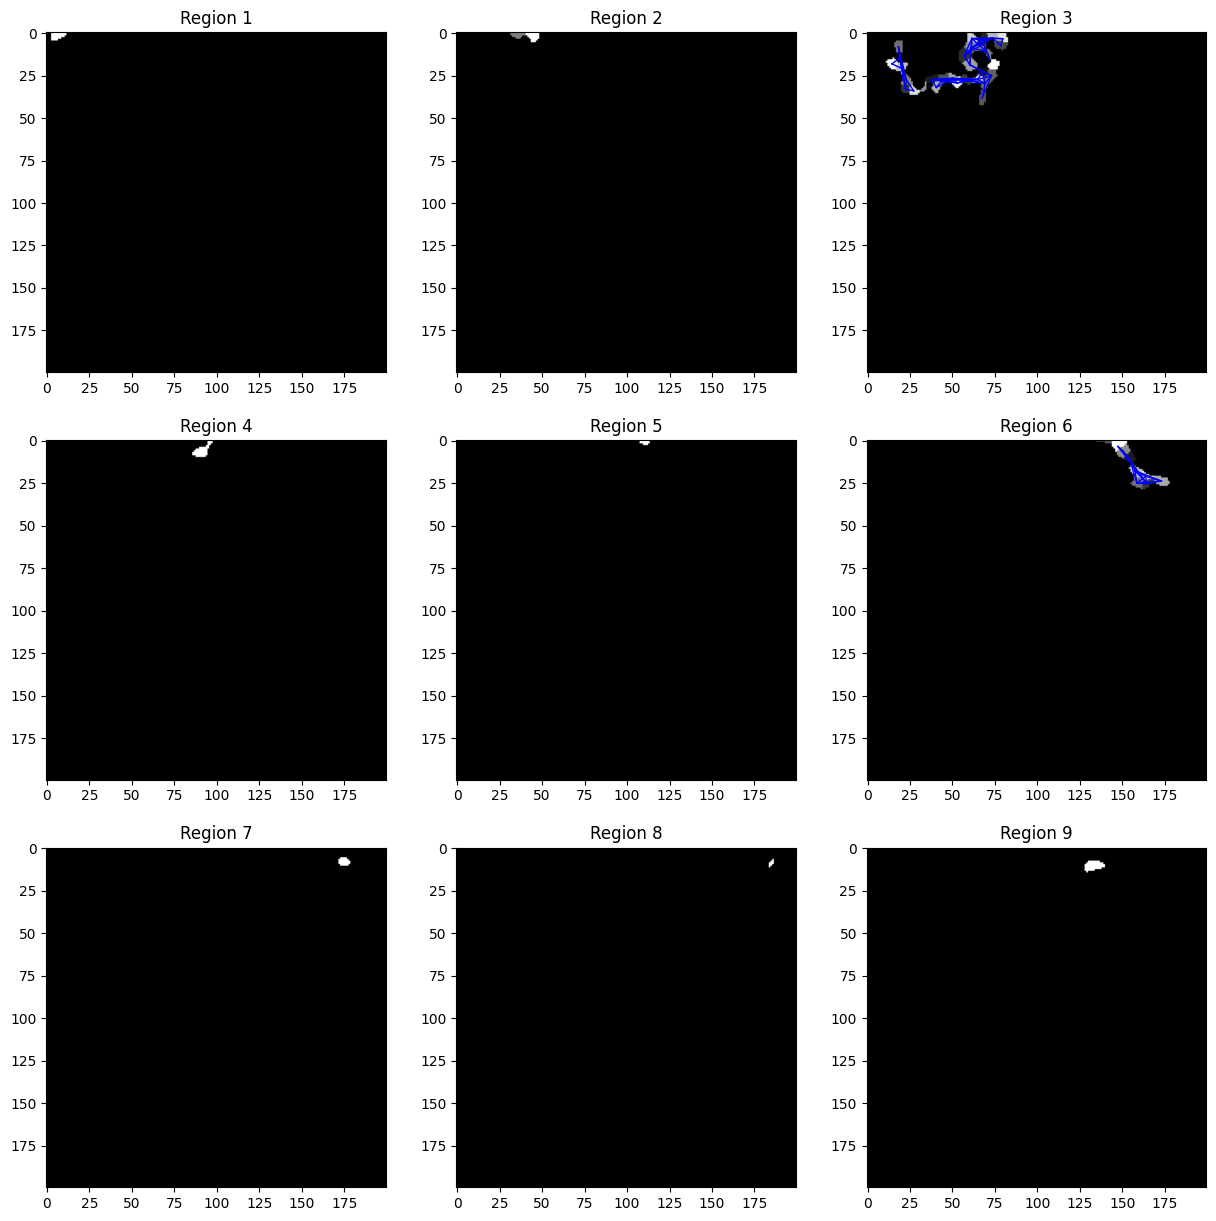

In [117]:
import random
import numpy as np
import matplotlib.pyplot as plt
from skimage.measure import label, find_contours
from scipy.spatial.distance import cdist
from skimage.draw import line

# Função para rotular clusters e encontrar seus contornos
def obter_contornos_dos_clusters(resultados_kmeans):
    contornos_por_regiao = []

    for regiao_clusterizada in resultados_kmeans:
        # Rotular cada cluster na região
        labeled_clusters = label(regiao_clusterizada)
        num_clusters = labeled_clusters.max()
        
        # Lista para armazenar contornos dos clusters na região atual
        contornos_da_regiao = []
        
        for cluster_num in range(1, num_clusters + 1):
            # Obter uma máscara do cluster atual
            mask = (labeled_clusters == cluster_num)
            # Encontrar contornos do cluster atual
            contornos = find_contours(mask, 0.5)
            contornos_da_regiao.append(contornos)
        
        contornos_por_regiao.append(contornos_da_regiao)

    return contornos_por_regiao

# Função para calcular a distância mínima entre dois contornos
def distancia_minima_entre_contornos(contorno1, contorno2):
    pontos_contorno1 = np.vstack(contorno1)
    pontos_contorno2 = np.vstack(contorno2)
    distancias = cdist(pontos_contorno1, pontos_contorno2)
    return distancias.min()

# Função para verificar se a linha entre dois pontos passa apenas por regiões clusterizadas
def linha_em_regiao_clusterizada(imagem, ponto1, ponto2):
    rr, cc = line(int(ponto1[0]), int(ponto1[1]), int(ponto2[0]), int(ponto2[1]))
    return np.all(imagem[rr, cc] > 0)

# Comprimento da lista resultados_kmeans
length = len(resultados_kmeans)

# Obter os contornos de todos os clusters em todas as regiões clusterizadas
contornos_por_regiao = obter_contornos_dos_clusters(resultados_kmeans)

# Inicializar uma figura
plt.figure(figsize=(15, 15))

# Loop sobre as regiões clusterizadas
for i in range(length):
    # Obter contornos e imagem da região clusterizada
    contornos_aleatorios = contornos_por_regiao[i]
    imagem_aleatoria = resultados_kmeans[i]
    
    # Inicializar o subplot
    plt.subplot(3, 3, i + 1)
    plt.imshow(imagem_aleatoria, cmap='gray')
    plt.title('Region {}'.format(i + 1))
    
    # Ligar os pontos médios dos contornos cujas linhas passam apenas por regiões clusterizadas
    for j in range(len(contornos_aleatorios)):
        for k in range(j + 1, len(contornos_aleatorios)):
            ponto_medio1 = np.mean(contornos_aleatorios[j][0], axis=0)
            ponto_medio2 = np.mean(contornos_aleatorios[k][0], axis=0)
            if linha_em_regiao_clusterizada(imagem_aleatoria, ponto_medio1, ponto_medio2):
                plt.plot([ponto_medio1[1], ponto_medio2[1]], 
                         [ponto_medio1[0], ponto_medio2[0]], 'b-', linewidth=1)

# Ajustar o layout
plt.tight_layout()

# Exibir o plot
plt.show()

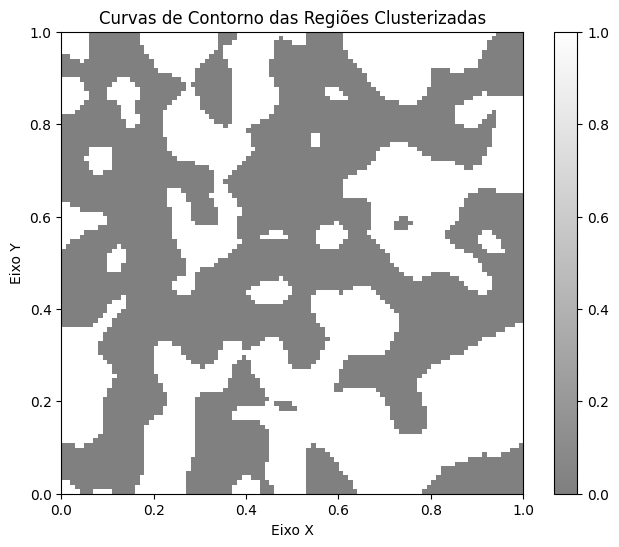

In [241]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage

# Supondo que regiao_aleatoria seja uma lista de regiões clusterizadas
# Vamos criar uma matriz bidimensional para representar essas regiões
# Para o exemplo, vou criar dados sintéticos

# Criação de dados sintéticos
np.random.seed(0)
data = np.random.rand(100, 100)

# Aplicação de um filtro para criar regiões clusterizadas (apenas para o exemplo)
data = ndimage.gaussian_filter(data, sigma=3)

# Threshold para criar regiões (valores arbitrários para exemplo)
threshold = 0.5
regions = data > threshold

# Plotando as curvas de contorno
plt.figure(figsize=(8, 6))
contours = plt.contour(regions, levels=[0.5], colors='black')
plt.imshow(regions, extent=[0, 1, 0, 1], origin='lower', cmap='gray', alpha=0.5)
plt.colorbar()
plt.title('Curvas de Contorno das Regiões Clusterizadas')
plt.xlabel('Eixo X')
plt.ylabel('Eixo Y')
plt.show()


## Connectivity

In [302]:
import porespy as ps

# Generate a synthetic 2D porous material image
im = ps.generators.blobs(shape=[200, 200], porosity=0.28, blobiness=2)
im = im.astype('uint8')
# Threshold the image to separate void space and solid matrix
threshold_value = 0.5  # Adjust this threshold as needed
#binary_image = (im > threshold_value).astype(int)
binary_image = im > threshold_value
# Label connected components in the binary image
labeled_image, num_labels = ndi.label(binary_image)

In [303]:
labeled_image.shape

(200, 200)

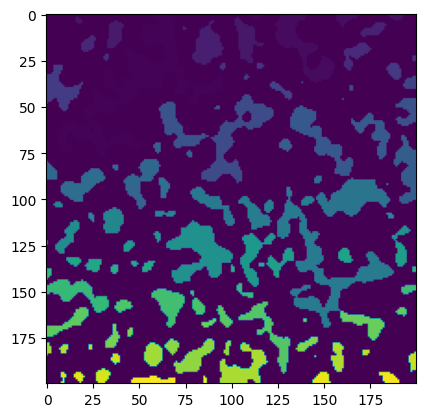

In [304]:
plt.imshow(labeled_image)

Random number: 54


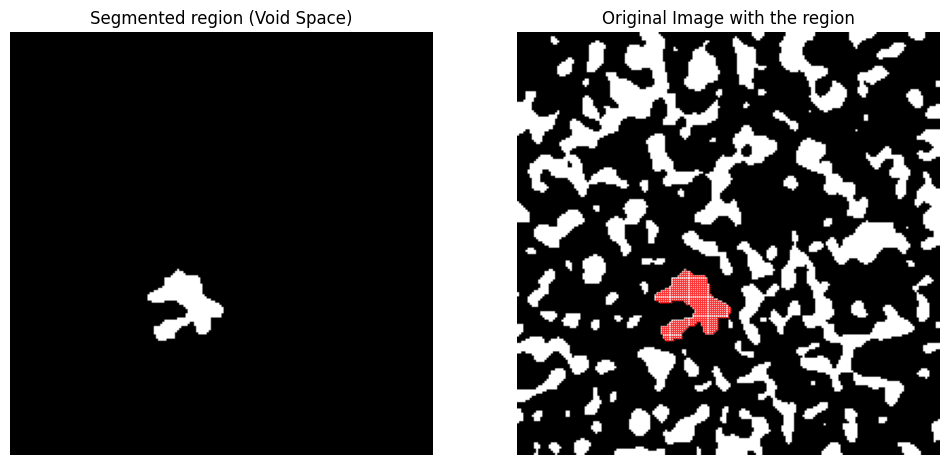

In [305]:
# Lista para salvar as regiões segmentadas (void space)
regioes_segmentadas = []

# Lista para salvar as coordenadas de cada região
coordenadas_poros = []

# Iterar sobre os diferentes rótulos de regiões na imagem rotulada
for label in range(1, num_labels + 1):
    # Encontrar os índices dos pixels da região na imagem rotulada
    indices_regiao = np.where(labeled_image == label)

    # Salvar as coordenadas x e y dos pixels da região na imagem original
    coords_x, coords_y = indices_regiao[1], indices_regiao[0]
    coordenadas_poros.append((coords_x, coords_y))

    # Extrair a região segmentada (void space) da imagem original
    regiao_segmentada = np.zeros_like(im)
    regiao_segmentada[coords_y, coords_x] = 1  # Atribuir 1 aos pixels da região
    regioes_segmentadas.append(regiao_segmentada)

import random
random_number = random.randint(0, len(regioes_segmentadas))  # Generates a random integer between 1 and 100 (inclusive)
print("Random number:", random_number)

# Exemplo de acesso a uma região segmentada e suas coordenadas
indice_da_regiao = random_number  # Índice da região desejada
regiao_segmentada_desejada = regioes_segmentadas[indice_da_regiao]
coordenadas_da_regiao_desejada = coordenadas_poros[indice_da_regiao]



# Visualizar a região segmentada e as coordenadas
plt.figure(figsize=(12, 6))
plt.subplot(121)
plt.imshow(regiao_segmentada_desejada, cmap='gray')
plt.title('Segmented region (Void Space)')
plt.axis('off')

plt.subplot(122)
plt.imshow(binary_image, cmap='gray')
plt.plot(coordenadas_da_regiao_desejada[0], coordenadas_da_regiao_desejada[1], 'r.', markersize=1)
plt.title('Original Image with the region')
plt.axis('off')

plt.show()

## Apply the cluster tecnique: k means

In [295]:
# The number of pixels to consider a pore
pore_number = 30

In [296]:
distancia_maxima= pore_number * 0.20
distancia_maxima

6.0

In [306]:
import numpy as np
from sklearn.cluster import KMeans
from skimage.measure import find_contours

def apply_kmeans_to_region(region_segmentada, pore_number):
    # Obter os pixels que são representados por 1 na região segmentada
    pixels_0 = np.argwhere(region_segmentada == 1)

    # Determinar o número de vezes que len(pixels_0) excede pore_number
    excessos = len(pixels_0) // pore_number

    # Ajustar o número de clusters com base nos excessos
    num_clusters = max(1, excessos)

    # Aplicar K-means aos pixels 0 para segmentá-los em clusters
    kmeans = KMeans(n_clusters=num_clusters, random_state=42)
    kmeans.fit(pixels_0)

    # Obter os rótulos dos clusters atribuídos aos pixels 0
    labels = kmeans.labels_

    # Criar uma matriz com os rótulos dos clusters nas posições dos pixels 0
    clustered_region = np.zeros_like(region_segmentada)
    for label, pixel in zip(labels, pixels_0):
        clustered_region[pixel[0], pixel[1]] = label + 1  # Adicionar 1 para evitar label 0

    # Calcular os centros dos clusters
    cluster_centers = kmeans.cluster_centers_

    # Encontrar os contornos de cada cluster
    contornos_por_cluster = []
    for i in range(num_clusters):
        mask = clustered_region == (i + 1)  # Criar uma máscara para o cluster atual
        contornos = find_contours(mask, 0.5)  # Encontrar os contornos do cluster atual
        contornos_por_cluster.append(contornos)

    # Retornar a região clusterizada, o número de clusters, as coordenadas dos centros dos clusters e os contornos de cada cluster
    return clustered_region, num_clusters, cluster_centers, contornos_por_cluster



import numpy as np
from skimage.measure import label, regionprops

def calculate_aspect_ratios(clustered_region):
    # Rotular a imagem para obter clusters individuais
    labeled_image = label(clustered_region)
    regions = regionprops(labeled_image)

    aspect_ratios = []
    for region in regions:
        major_axis_length = region.major_axis_length
        minor_axis_length = region.minor_axis_length

        #print(f"Major axis length: {major_axis_length}, Minor axis length: {minor_axis_length}")  # Informações para depuração

        if major_axis_length > 0:  # Evitar divisão por zero
            aspect_ratio = minor_axis_length / major_axis_length
        else:
            aspect_ratio = 0
        aspect_ratios.append(aspect_ratio)

    return aspect_ratios


def calculate_areas(clustered_region):
    # Rotular a imagem para obter clusters individuais
    labeled_image = label(clustered_region)
    regions = regionprops(labeled_image)

    #aspect_ratios = []
    areas = []
    for region in regions:
        ##major_axis_length = region.major_axis_length
        ##minor_axis_length = region.minor_axis_length
        area = region.area

        # Calcular a razão de aspecto
        ##if major_axis_length > 0:  # Evitar divisão por zero
        ##    aspect_ratio = minor_axis_length / major_axis_length
        ##else:
        ##    aspect_ratio = 0
        
        ##aspect_ratios.append(aspect_ratio)
        areas.append(area)

    return areas



# Lista para armazenar as coordenadas dos centros de cada região clusterizada
coordenadas_centros_kmeans = []
resultados_kmeans = []
number_of_pores_kmeans = []
ratio_of_aspect_cluster_kmeans = []
areas_cluster_kmeans = []
contour_per_cluster = []

# Plotar as regiões segmentadas após a aplicação do K-means
for i, region_segmentada in enumerate(regioes_segmentadas, start=1):
    # Aplicar o K-means à região segmentada atual
    clustered_region_kmeans, n_por_kmeans, centros_kmeans, contour_k_means = apply_kmeans_to_region(region_segmentada, pore_number)

    # Armazenar as coordenadas dos centros dos clusters na lista
    coordenadas_centros_kmeans.append(centros_kmeans)
    resultados_kmeans.append(clustered_region_kmeans)
    number_of_pores_kmeans.append(n_por_kmeans)
    # Calcular as razões de aspecto dos clusters
    aspect_ratios_kmeans = calculate_aspect_ratios(clustered_region_kmeans)
    areas_kmeans = calculate_areas(clustered_region_kmeans)
    ratio_of_aspect_cluster_kmeans.append(aspect_ratios_kmeans)
    areas_cluster_kmeans.append(areas_kmeans)
    contour_per_cluster.append(contour_k_means)

In [307]:
len(resultados_kmeans), len(contour_per_cluster)

(109, 109)

Random number_kmean: 8 235 number_of_pores 7


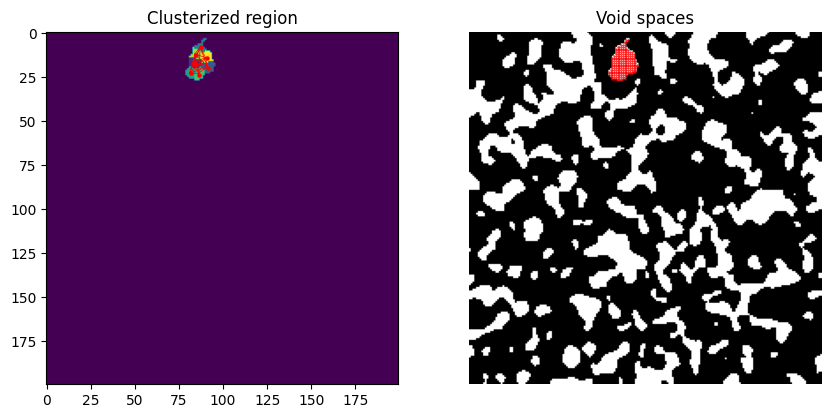

Número de ligações: 21


In [308]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import binary_dilation, label

# Gerar um número aleatório entre 0 e length-1
random_index = random.randint(0, len(resultados_kmeans) - 1)
random_number_kmean = random_index
numero_de_elementos_na_região = np.count_nonzero(resultados_kmeans[random_number_kmean])
print("Random number_kmean:", random_number_kmean, numero_de_elementos_na_região, 'number_of_pores', number_of_pores_kmeans[random_index])

# Obter a região clusterizada aleatória e seus centros
regiao_aleatoria = resultados_kmeans[random_number_kmean]
centros = coordenadas_centros_kmeans[random_number_kmean]

# Inicializar uma figura
plt.figure(figsize=(10, 10))

# Plotar a região clusterizada
plt.subplot(121)
plt.imshow(regiao_aleatoria)
plt.title('Clusterized region')
# Plotar os centros dos clusters
for centro in centros:
    plt.scatter(centro[1], centro[0], color='red', marker='o', s=5)

# Binarizar a imagem se necessário
binary_image = (regiao_aleatoria > 0).astype(int)

# Converte centros para inteiros
centros = [(int(centro[0]), int(centro[1])) for centro in centros]

# Aplicar dilatação até que os clusters estejam conectados
dilated_image = binary_image.copy()
numero_de_ligacoes = 0
conectados = False

while not conectados:
    dilated_image = binary_dilation(dilated_image)
    labeled_image, num_features = label(dilated_image)
    conectados = True
    for i in range(len(centros)):
        for j in range(i + 1, len(centros)):
            if labeled_image[centros[i][0], centros[i][1]] != labeled_image[centros[j][0], centros[j][1]]:
                conectados = False
            else:
                plt.plot([centros[i][1], centros[j][1]], [centros[i][0], centros[j][0]], 'r-', linewidth=0.5)  # 'r-' para uma linha vermelha
                numero_de_ligacoes += 1

# Exemplo de acesso a uma região segmentada e suas coordenadas
indice_da_regiao = random_number_kmean  # Índice da região desejada
regiao_segmentada_desejada = regioes_segmentadas[indice_da_regiao]
coordenadas_da_regiao_desejada = coordenadas_poros[indice_da_regiao]
plt.subplot(122)
plt.imshow(im, cmap='gray')
plt.plot(coordenadas_da_regiao_desejada[0], coordenadas_da_regiao_desejada[1], 'r.', markersize=1)
plt.title('Void spaces')
plt.axis('off')

# Mostrar o gráfico
plt.show()
# Exibir o número de ligações
print("Número de ligações:", numero_de_ligacoes)


In [309]:
import numpy as np
from sklearn.cluster import KMeans
from skimage.measure import find_contours

def apply_kmeans_to_region(region_segmentada, pore_number):
    # Obter os pixels que são representados por 1 na região segmentada
    pixels_0 = np.argwhere(region_segmentada == 1)

    # Determinar o número de vezes que len(pixels_0) excede pore_number
    excessos = len(pixels_0) // pore_number

    # Ajustar o número de clusters com base nos excessos
    num_clusters = max(1, excessos)

    # Aplicar K-means aos pixels 0 para segmentá-los em clusters
    kmeans = KMeans(n_clusters=num_clusters, random_state=42)
    kmeans.fit(pixels_0)

    # Obter os rótulos dos clusters atribuídos aos pixels 0
    labels = kmeans.labels_

    # Criar uma matriz com os rótulos dos clusters nas posições dos pixels 0
    clustered_region = np.zeros_like(region_segmentada)
    for label, pixel in zip(labels, pixels_0):
        clustered_region[pixel[0], pixel[1]] = label + 1  # Adicionar 1 para evitar label 0

    # Calcular os centros dos clusters
    cluster_centers = kmeans.cluster_centers_

    # Encontrar os contornos de cada cluster
    contornos_por_cluster = []
    for i in range(num_clusters):
        mask = clustered_region == (i + 1)  # Criar uma máscara para o cluster atual
        contornos = find_contours(mask, 0.5)  # Encontrar os contornos do cluster atual
        contornos_por_cluster.append(contornos)

    # Retornar a região clusterizada, o número de clusters, as coordenadas dos centros dos clusters e os contornos de cada cluster
    return clustered_region, num_clusters, cluster_centers, contornos_por_cluster



import numpy as np
from skimage.measure import label, regionprops

def calculate_aspect_ratios(clustered_region):
    # Rotular a imagem para obter clusters individuais
    labeled_image = label(clustered_region)
    regions = regionprops(labeled_image)

    aspect_ratios = []
    for region in regions:
        major_axis_length = region.major_axis_length
        minor_axis_length = region.minor_axis_length

        #print(f"Major axis length: {major_axis_length}, Minor axis length: {minor_axis_length}")  # Informações para depuração

        if major_axis_length > 0:  # Evitar divisão por zero
            aspect_ratio = minor_axis_length / major_axis_length
        else:
            aspect_ratio = 0
        aspect_ratios.append(aspect_ratio)

    return aspect_ratios


def calculate_areas(clustered_region):
    # Rotular a imagem para obter clusters individuais
    labeled_image = label(clustered_region)
    regions = regionprops(labeled_image)

    #aspect_ratios = []
    areas = []
    for region in regions:
        ##major_axis_length = region.major_axis_length
        ##minor_axis_length = region.minor_axis_length
        area = region.area

        # Calcular a razão de aspecto
        ##if major_axis_length > 0:  # Evitar divisão por zero
        ##    aspect_ratio = minor_axis_length / major_axis_length
        ##else:
        ##    aspect_ratio = 0
        
        ##aspect_ratios.append(aspect_ratio)
        areas.append(area)

    return areas







# Lista para armazenar as coordenadas dos centros de cada região clusterizada
coordenadas_centros_kmeans = []
resultados_kmeans = []
number_of_pores_kmeans = []
ratio_of_aspect_cluster_kmeans = []
areas_cluster_kmeans = []
contour_per_cluster = []

# Plotar as regiões segmentadas após a aplicação do K-means
for i, region_segmentada in enumerate(regioes_segmentadas, start=1):
    # Aplicar o K-means à região segmentada atual
    clustered_region_kmeans, n_por_kmeans, centros_kmeans, contour_k_means = apply_kmeans_to_region(region_segmentada, pore_number)

    # Armazenar as coordenadas dos centros dos clusters na lista
    coordenadas_centros_kmeans.append(centros_kmeans)
    resultados_kmeans.append(clustered_region_kmeans)
    number_of_pores_kmeans.append(n_por_kmeans)
    # Calcular as razões de aspecto dos clusters
    aspect_ratios_kmeans = calculate_aspect_ratios(clustered_region_kmeans)
    areas_kmeans = calculate_areas(clustered_region_kmeans)
    ratio_of_aspect_cluster_kmeans.append(aspect_ratios_kmeans)
    areas_cluster_kmeans.append(areas_kmeans)
    contour_per_cluster.append(contour_k_means)

Random number_kmean: 75 201 number_of_pores 19


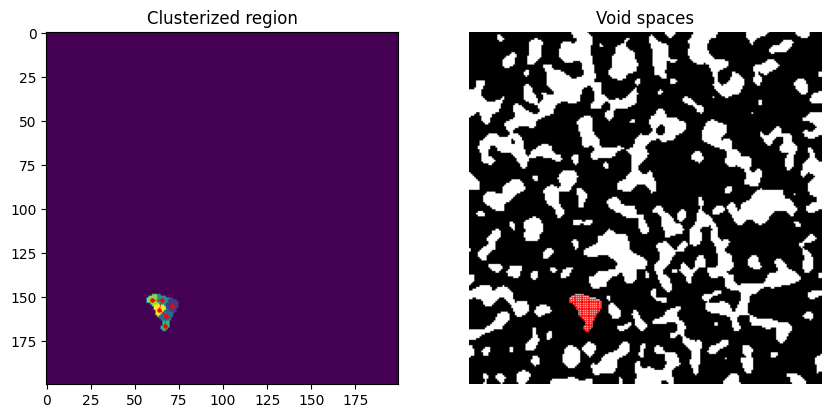

Número de ligações: 4


In [312]:
import random
import matplotlib.pyplot as plt

# Comprimento da lista resultados_kmeans
length = len(resultados_kmeans)

# Gerar um número aleatório entre 0 e length-1
random_index = random.randint(0, length - 1)

# Gerar um número aleatório entre 0 e o comprimento da lista de resultados - 1
random_number_kmean = random_index
#random_number_kmean = 0
numero_de_elementos_na_região = np.count_nonzero(resultados_kmeans[random_number_kmean])
print("Random number_kmean:", random_number_kmean, numero_de_elementos_na_região, 'number_of_pores', number_of_pores_kmeans[random_number])
# Obter a região clusterizada aleatória e seus centros
regiao_aleatoria = resultados_kmeans[random_number_kmean]
centros = coordenadas_centros_kmeans[random_number_kmean]

# Definir uma distância máxima entre centros para considerá-los lado a lado
##distancia_maxima = 5.5  # Ajuste conforme necessário

# Inicializar uma figura
plt.figure(figsize=(10, 10))

# Plotar a região clusterizada
plt.subplot(121)
plt.imshow(regiao_aleatoria)
plt.title('Clusterized region')
# Plotar os centros dos clusters
for centro in centros:
    plt.scatter(centro[1], centro[0], color='red', marker='o', s=5)

# Função para calcular a distância entre dois pontos
def distancia_entre_pontos(p1, p2):
    return ((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2)**0.5

# Ligando os centros dos clusters de regiões lado a lado
# Inicialize uma variável para contar o número de ligações
numero_de_ligacoes = 0
for i in range(len(centros)):
    for j in range(i + 1, len(centros)):
        distancia = distancia_entre_pontos(centros[i], centros[j])
        if distancia <= distancia_maxima:
            plt.plot([centros[i][1], centros[j][1]], [centros[i][0], centros[j][0]], 'r-', linewidth=0.5)  # 'r-' para uma linha vermelha
            numero_de_ligacoes += 1

# Exemplo de acesso a uma região segmentada e suas coordenadas
indice_da_regiao = random_number_kmean  # Índice da região desejada
regiao_segmentada_desejada = regioes_segmentadas[indice_da_regiao]
coordenadas_da_regiao_desejada = coordenadas_poros[indice_da_regiao]
plt.subplot(122)
plt.imshow(im, cmap='gray')
plt.plot(coordenadas_da_regiao_desejada[0], coordenadas_da_regiao_desejada[1], 'r.', markersize=1)
plt.title('Void spaces')
plt.axis('off')

# Mostrar o gráfico


plt.show()
# Exibir o número de ligações
print("Número de ligações:", numero_de_ligacoes)

Random number_kmean: 94 281 number_of_pores 9


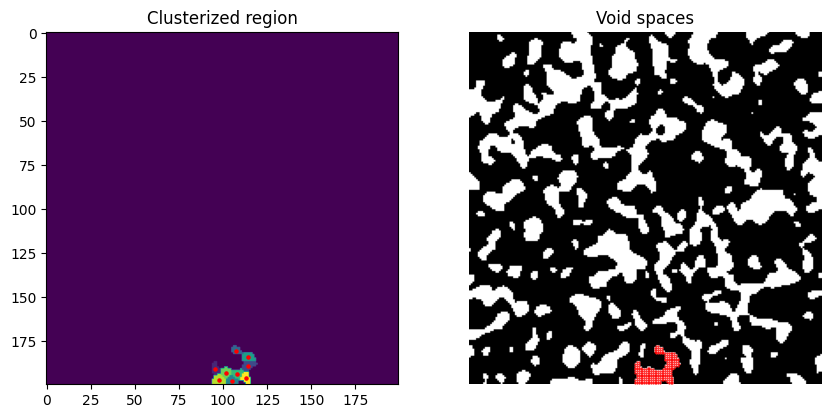

Número de ligações: 0


In [324]:
import numpy as np
import random
import matplotlib.pyplot as plt
from scipy.ndimage import label, generate_binary_structure

# Função para verificar se duas regiões estão adjacentes
def are_adjacent(label_image, label1, label2):
    structure = generate_binary_structure(2, 2)  # Conectividade 8
    dilated_label1 = label(label_image == label1, structure=structure)[0]
    dilated_label2 = label(label_image == label2, structure=structure)[0]
    return np.any(dilated_label1 & dilated_label2)

# Gerar um número aleatório entre 0 e length-1
random_index = random.randint(0, len(resultados_kmeans) - 1)
random_number_kmean = random_index
numero_de_elementos_na_região = np.count_nonzero(resultados_kmeans[random_number_kmean])
print("Random number_kmean:", random_number_kmean, numero_de_elementos_na_região, 'number_of_pores', number_of_pores_kmeans[random_index])

# Obter a região clusterizada aleatória e seus centros
regiao_aleatoria = resultados_kmeans[random_number_kmean]
centros = coordenadas_centros_kmeans[random_number_kmean]

# Inicializar uma figura
plt.figure(figsize=(10, 10))

# Plotar a região clusterizada
plt.subplot(121)
plt.imshow(regiao_aleatoria)
plt.title('Clusterized region')
# Plotar os centros dos clusters
for centro in centros:
    plt.scatter(centro[1], centro[0], color='red', marker='o', s=5)

# Binarizar a imagem se necessário
binary_image = (regiao_aleatoria > 0).astype(int)

# Rotular componentes conectados
labeled_image, num_labels = label(binary_image)

# Inicialize uma variável para contar o número de ligações
numero_de_ligacoes = 0

# Verificar adjacência entre rótulos
for i in range(1, num_labels + 1):
    for j in range(i + 1, num_labels + 1):
        if are_adjacent(binary_image, i, j):
            numero_de_ligacoes += 1
            plt.plot([centros[i-1][1], centros[j-1][1]], [centros[i-1][0], centros[j-1][0]], 'r-', linewidth=0.5)  # 'r-' para uma linha vermelha

# Exemplo de acesso a uma região segmentada e suas coordenadas
indice_da_regiao = random_number_kmean  # Índice da região desejada
regiao_segmentada_desejada = regioes_segmentadas[indice_da_regiao]
coordenadas_da_regiao_desejada = coordenadas_poros[indice_da_regiao]
plt.subplot(122)
plt.imshow(im, cmap='gray')
plt.plot(coordenadas_da_regiao_desejada[0], coordenadas_da_regiao_desejada[1], 'r.', markersize=1)
plt.title('Void spaces')
plt.axis('off')

# Mostrar o gráfico
plt.show()

# Exibir o número de ligações
print("Número de ligações:", numero_de_ligacoes)

In [325]:
labeled_image

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [327]:
unique_values = np.unique(regiao_aleatoria)
print("Valores únicos que representam cada região clusterizada:", unique_values)

Valores únicos que representam cada região clusterizada: [0 1 2 3 4 5 6 7 8 9]


In [335]:
import numpy as np
from skimage.graph import route_through_array

In [336]:
image = np.array([[1, 3], [10, 12]])
image

array([[ 1,  3],
       [10, 12]])

In [337]:
# Forbid diagonal steps
route_through_array(image, [0, 0], [1, 1], fully_connected=False)

([(0, 0), (0, 1), (1, 1)], 9.5)

In [371]:
# Now allow diagonal steps: the path goes directly from start to end
route_through_array(image, [0, 0], [2, 2])

([(0, 0), (0, 1), (1, 2), (2, 2)], 17.86396103067893)

In [372]:
route_through_array(image, [0, 0], [1, 1], fully_connected=True,
geometric=False)

([(0, 0), (1, 1)], 7.0)

In [373]:
# Larger array where we display the path that is selected
image = np.arange((36)).reshape((6, 6))
image

array([[ 0,  1,  2,  3,  4,  5],
       [ 6,  7,  8,  9, 10, 11],
       [12, 13, 14, 15, 16, 17],
       [18, 19, 20, 21, 22, 23],
       [24, 25, 26, 27, 28, 29],
       [30, 31, 32, 33, 34, 35]])

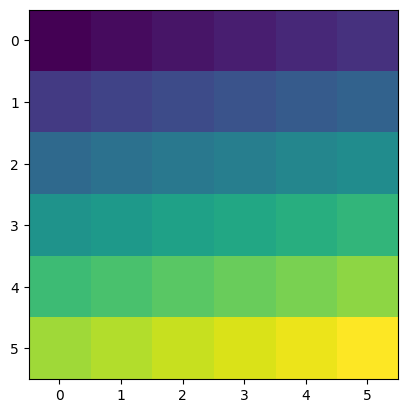

In [374]:
plt.imshow(image)

In [375]:
# Find the path with lowest cost
indices, weight = route_through_array(image, (1, 1), (2, 2))

In [376]:
indices = np.stack(indices, axis=-1)
path = np.zeros_like(image)

In [377]:
path[indices[0], indices[1]] = 1
path

array([[0, 0, 0, 0, 0, 0],
       [0, 1, 0, 0, 0, 0],
       [0, 0, 1, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0]])

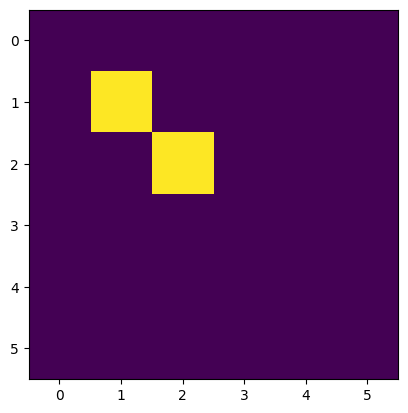

In [378]:
plt.imshow(path)

In [465]:
import porespy as ps

# Generate a synthetic 2D porous material image
im = ps.generators.blobs(shape=[200, 200], porosity=0.28, blobiness=2)
im = im.astype('uint8')
# Threshold the image to separate void space and solid matrix
threshold_value = 0.5  # Adjust this threshold as needed
#binary_image = (im > threshold_value).astype(int)
binary_image = im > threshold_value
# Label connected components in the binary image
labeled_image, num_labels = ndi.label(binary_image)

In [466]:
#im = 1 - im

In [467]:
# Find the path with lowest cost
indices, weight = route_through_array(im, (0, 0), (150, 150))

In [468]:
indices = np.stack(indices, axis=-1)
path = np.zeros_like(im)

In [469]:
path[indices[0], indices[1]] = 1
path

array([[1, 0, 0, ..., 0, 0, 0],
       [0, 1, 0, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], dtype=uint8)

In [470]:
im

array([[0, 0, 0, ..., 1, 1, 1],
       [0, 0, 0, ..., 1, 1, 1],
       [0, 0, 0, ..., 1, 1, 1],
       ...,
       [0, 0, 0, ..., 1, 1, 1],
       [0, 0, 0, ..., 1, 1, 1],
       [0, 0, 0, ..., 1, 1, 1]], dtype=uint8)

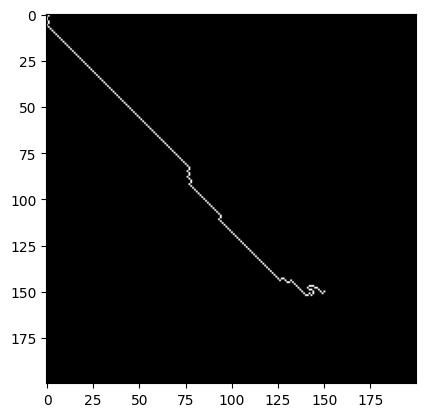

In [471]:
plt.imshow(path, cmap='gray')

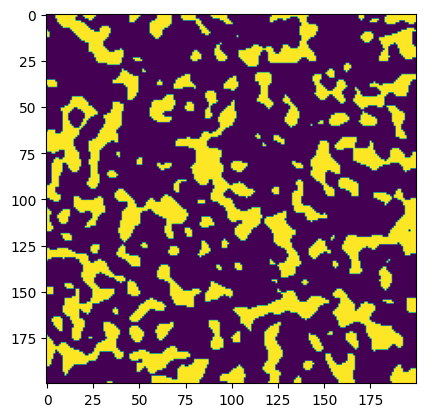

In [472]:
plt.imshow(im)

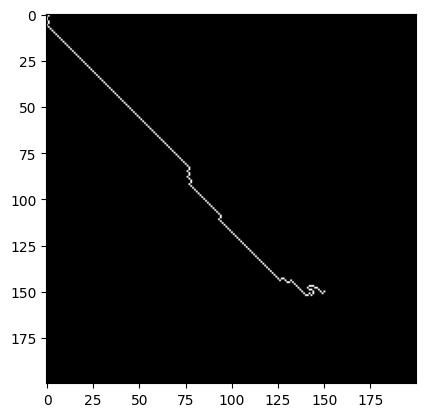

In [473]:
indices, weight = route_through_array(im, (0, 0), (150, 150))
indices = np.stack(indices, axis=-1)
path = np.zeros_like(im)
path[indices[0], indices[1]] = 1

plt.imshow(path, cmap='gray')
plt.show()

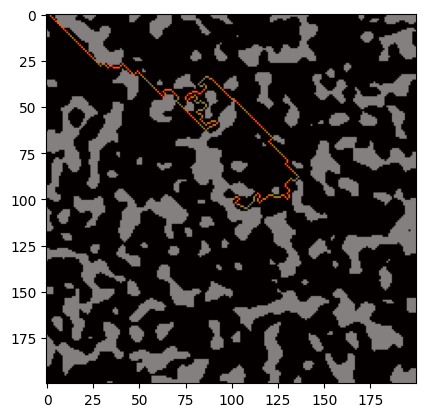

In [474]:
# Encontrar o caminho de menor custo
indices, weight = route_through_array(im, (0, 0), (100, 100))
indices = np.stack(indices, axis=-1)
path = np.zeros_like(im)
path[indices[0], indices[1]] = 1

# Mostrar a imagem original com o caminho sobreposto
plt.imshow(im, cmap='gray')  # Mostrar a imagem original
plt.imshow(path, cmap='hot', alpha=0.5)  # Sobrepor o caminho em uma cor diferente e com transparência
plt.show()

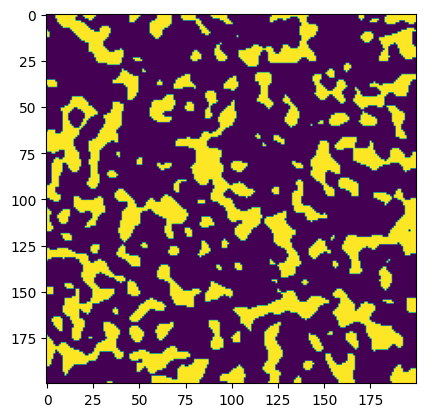

In [475]:
plt.imshow(im)

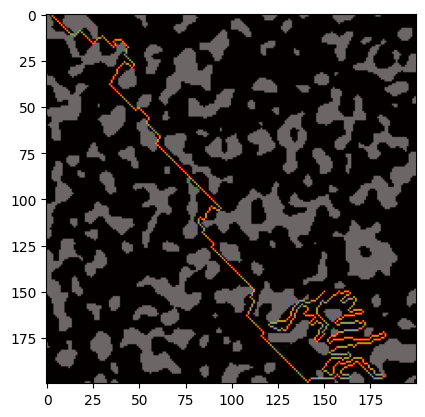

In [477]:


# Gerar uma imagem porosa sintética
im = ps.generators.blobs(shape=[200, 200], porosity=0.28, blobiness=2)
im = im.astype('uint8')

# Definir o valor de limiar
threshold_value = 0.5
binary_image = im > threshold_value

# Rotular as componentes conectadas
from scipy import ndimage as ndi
labeled_image, num_labels = ndi.label(binary_image)

# Encontrar o caminho de menor custo nas regiões representadas por 0
indices, weight = route_through_array(im, (0, 0), (150, 150), fully_connected=True, geometric=True)
indices = np.stack(indices, axis=-1)
path = np.zeros_like(im)
path[indices[0], indices[1]] = 1

# Mostrar a imagem original com o caminho sobreposto
plt.imshow(im, cmap='gray')  # Mostrar a imagem original
plt.imshow(path, cmap='hot', alpha=0.6)  # Sobrepor o caminho em uma cor diferente e com transparência
plt.show()

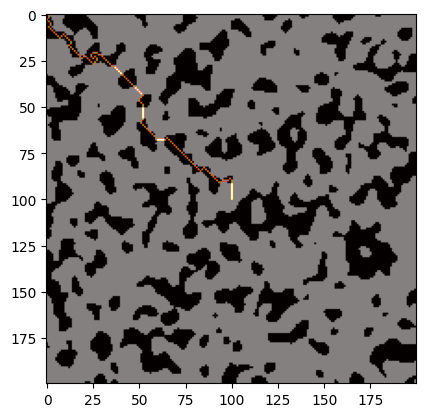

In [478]:
im = 1 - im
# Encontrar o caminho de menor custo
indices, weight = route_through_array(im, (0, 0), (100, 100))
indices = np.stack(indices, axis=-1)
path = np.zeros_like(im)
path[indices[0], indices[1]] = 1

# Mostrar a imagem original com o caminho sobreposto
plt.imshow(im, cmap='gray')  # Mostrar a imagem original
plt.imshow(path, cmap='hot', alpha=0.5)  # Sobrepor o caminho em uma cor diferente e com transparência
plt.show()